# 09 — Unified LambdaMART (train-library candidates only)

Trains a **LightGBM `LGBMRanker` (`objective="lambdarank"`)** on notebook 04's already-computed
pair-feature tables -- no new spectral computation, no analogue-transfer or fingerprint-prediction
features (those need notebooks 06-08, deliberately deferred this session: no external candidate
databases or pretrained embeddings exist locally).

Scope, precisely:

- Trains ONLY on the known-spectrum regime (the one regime with non-trivial spectral signal --
  notebook 04/05 both establish that unseen-connectivity's spectral `target_score_coverage` is
  exactly 0.000 by construction, so there is nothing for a model to learn there beyond mass).
- Uses `casmi.ranking.feature_policy.SPECTRAL_RANKING_FEATURE_POLICY` -- the SAME 9
  hand-specified `model_features` notebook 04's classical baselines used, imported (not
  redefined) so the two notebooks can never silently drift out of sync.
- Cross-validates with the EXISTING connectivity-safe fold assignment (`connectivity_folds`,
  already attached to every dev-ranking query as `fold`) -- leave-one-fold-out, out-of-fold (OOF)
  predictions only, so every reported metric is on data the scoring model never trained on.
- Compares the trained ranker against notebook 04's registered classical baselines with
  `casmi.validation.bootstrap.paired_bootstrap_report` (not a raw point-estimate comparison).
- Re-runs notebook 05's shortcut-detection controls (candidate-order invariance, masked-spectrum
  sensitivity) against the TRAINED model's predictions specifically -- a flexible model has no
  documented, benign tie-breaking rule the way `rank_candidates` does, so these controls matter
  more here than they did for the classical scores.
- Produces genuine (unlabeled) rank predictions for the real competition test queries as an
  artifact -- the test set has no ground truth locally, so those predictions are saved, not
  scored, laying the groundwork for Kaggle offline packaging without overclaiming a test score
  this notebook cannot actually compute.

In [1]:
import sys, json, time
from pathlib import Path

NOTEBOOK_START_TIME = time.time()

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from casmi.paths import get_project_paths
from casmi.io.artifacts import load_artifact
from casmi.ranking.evaluation import rank_candidates, ranking_metrics, true_candidate_rank, per_query_reciprocal_rank, per_query_hit
from casmi.ranking.feature_policy import SPECTRAL_RANKING_FEATURE_POLICY, assert_no_prohibited_features
from casmi.ranking.features import compute_pair_spectral_scores
from casmi.validation.checks import CheckResult, summarize_checks
from casmi.validation.baseline_registry import load_baseline, register_baseline
from casmi.validation.bootstrap import paired_bootstrap_report

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

SEED = 42
N_BOOTSTRAP = 5000
LGBM_PARAMS = dict(
    objective="lambdarank", metric="ndcg", n_estimators=300, learning_rate=0.05,
    num_leaves=31, min_child_samples=20, random_state=SEED, verbosity=-1,
)

paths = get_project_paths()
CG_INTERIM = paths.interim / "candidate_generation"
CG_PROCESSED = paths.processed / "candidate_generation"
RANK_INTERIM = paths.interim / "spectral_ranking"
RANK_PROCESSED = paths.processed / "spectral_ranking"
LMART_PROCESSED = paths.processed / "lambdamart"
FIGURE_DIR = paths.figures / "lambdamart"
LMART_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_REGISTRY_PATH = paths.processed / "baseline_registry.json"

MODEL_FEATURES = SPECTRAL_RANKING_FEATURE_POLICY.model_features
checks = []

## 2. Load notebook 03/04/05 artifacts (no recomputation)

In [2]:
with open(CG_PROCESSED / "candidate_generation_contract.json") as f:
    contract = json.load(f)
notebook_04_baselines = load_baseline("notebook_04_classical_baselines", BASELINE_REGISTRY_PATH)
assert notebook_04_baselines is not None, "notebook 04 must be run first -- its baseline_registry entry is required here"
print(f"candidate-generation status: {contract['status']}")
print(f"notebook 04 baselines: known_spectrum best = {max(notebook_04_baselines['known_spectrum'].values()):.4f} MRR@25")

dev_ranking_queries = pd.read_parquet(RANK_INTERIM / "dev_ranking_queries.parquet")
pair_features_dev_known = pd.read_parquet(RANK_INTERIM / "pair_features_dev_known_spectrum.parquet")
pair_features_dev_unseen = pd.read_parquet(RANK_INTERIM / "pair_features_dev_unseen_connectivity.parquet")
pair_features_test = pd.read_parquet(RANK_INTERIM / "pair_features_test.parquet")
test_queries = pd.read_parquet(CG_INTERIM / "test_queries.parquet")

all_dev_query_ids = dev_ranking_queries["query_id"].tolist()
print(f"dev_ranking_queries: {len(dev_ranking_queries):,} queries, {dev_ranking_queries['fold'].nunique()} connectivity-safe folds")
print(f"pair_features_dev_known: {pair_features_dev_known.shape}")
print(f"pair_features_test (UNLABELED -- real competition test set): {pair_features_test.shape}")
checks.append(CheckResult("upstream artifacts loaded", True, "notebook 03/04 artifacts loaded without recomputation"))

candidate-generation status: PROVISIONAL
notebook 04 baselines: known_spectrum best = 0.6908 MRR@25


dev_ranking_queries: 1,000 queries, 5 connectivity-safe folds
pair_features_dev_known: (248027, 14)
pair_features_test (UNLABELED -- real competition test set): (471173, 13)


## 3. Feature-policy governance check

Fails loudly, before any training, if a leakage-prone column ever slipped into the model-input
frame -- the same guardrail notebook 04 demonstrated on the classical scores, now exercised on
the actual columns handed to `LGBMRanker.fit`.

In [3]:
train_table = pair_features_dev_known.merge(dev_ranking_queries[["query_id", "fold", "true_connectivity_key"]], on="query_id", how="left")
assert train_table["fold"].notna().all(), "every known-spectrum pair row must map to a query with an assigned connectivity-safe fold"

# demonstrate the guardrail actually catches a violation, using the SAME raw pair table notebook
# 04 showed gets rejected -- before trusting it to pass MODEL_FEATURES through cleanly below.
try:
    assert_no_prohibited_features(train_table, SPECTRAL_RANKING_FEATURE_POLICY)
    raise RuntimeError("expected AssertionError: raw pair table includes has_reference_spectrum/n_reference_spectra")
except AssertionError as e:
    print(f"[EXPECTED] raw pair table correctly REJECTED: {e}")

assert_no_prohibited_features(train_table[MODEL_FEATURES], SPECTRAL_RANKING_FEATURE_POLICY)
print(f"\nmodel input columns ({len(MODEL_FEATURES)}): {MODEL_FEATURES}")
print("[PASS] model-input frame (MODEL_FEATURES subset) contains no prohibited (leakage-prone) columns")
checks.append(CheckResult("feature-policy governance enforced before training", True,
                           f"{len(MODEL_FEATURES)} model features, 0 prohibited columns present"))

[EXPECTED] raw pair table correctly REJECTED: prohibited (leakage-prone) features present in model input: ['has_reference_spectrum', 'n_reference_spectra']

model input columns (9): ['abs_mass_error_ppm', 'cosine_max', 'cosine_top3_mean', 'modified_cosine_max', 'modified_cosine_top3_mean', 'peak_overlap_frac_max', 'peak_overlap_frac_top3_mean', 'neutral_loss_cosine_max', 'neutral_loss_cosine_top3_mean']
[PASS] model-input frame (MODEL_FEATURES subset) contains no prohibited (leakage-prone) columns


## 4. Connectivity-safe leave-one-fold-out training

Reuses the SAME 5 connectivity-safe folds notebook 02/03/04 already computed
(`connectivity_folds`, joined here via `dev_ranking_queries['fold']`) -- no new fold-generation
logic, so no new leakage-surface. Every prediction reported below is out-of-fold: the model that
scored a query's candidates never saw that query's connectivity during training.

In [4]:
oof_scores = pd.Series(np.nan, index=train_table.index)
fold_models = {}
fold_diagnostics = []

for held_out_fold in sorted(train_table["fold"].unique()):
    tr = train_table[train_table["fold"] != held_out_fold].sort_values("query_id")
    va = train_table[train_table["fold"] == held_out_fold].sort_values("query_id")

    tr_group = tr.groupby("query_id", sort=True).size().to_numpy()
    model = lgb.LGBMRanker(**LGBM_PARAMS)
    model.fit(tr[MODEL_FEATURES], tr["is_true_candidate"].astype(int), group=tr_group)

    va_scores = model.predict(va[MODEL_FEATURES])
    oof_scores.loc[va.index] = va_scores
    fold_models[held_out_fold] = model
    fold_diagnostics.append({"held_out_fold": held_out_fold, "n_train_rows": len(tr), "n_train_queries": tr["query_id"].nunique(),
                              "n_val_rows": len(va), "n_val_queries": va["query_id"].nunique()})

fold_diagnostics_df = pd.DataFrame(fold_diagnostics)
display(fold_diagnostics_df)
assert oof_scores.notna().all(), "every training row must receive an out-of-fold prediction exactly once"
train_table = train_table.assign(lambdamart_score=oof_scores)
checks.append(CheckResult("out-of-fold predictions cover every training row exactly once", oof_scores.notna().all(),
                           f"{len(fold_diagnostics_df)} folds, {len(train_table):,} rows"))

,held_out_fold,n_train_rows,n_train_queries,n_val_rows,n_val_queries
0,0,200916,800,47111,196
1,1,198547,799,49480,197
2,2,199663,800,48364,196
3,3,198649,785,49378,211
4,4,194333,800,53694,196


## 5. Out-of-fold evaluation (known-spectrum / Mode A)

Directly comparable to notebook 04's `end_to_end_mrr_at_25` numbers -- same queries, same
denominator (`all_dev_query_ids`), same `ranking_metrics` call.

In [5]:
lmart_ranked = rank_candidates(train_table.assign(score=train_table["lambdamart_score"]), score_col="score", ascending=False)
lmart_metrics = ranking_metrics(lmart_ranked, all_dev_query_ids, k_values=(1, 5, 10, 25))
lmart_ranks = true_candidate_rank(lmart_ranked).reindex(all_dev_query_ids)
lmart_per_query_rr = per_query_reciprocal_rank(lmart_ranks, k=25)

best_classical_signal = max(notebook_04_baselines["known_spectrum"], key=notebook_04_baselines["known_spectrum"].get)
best_classical_mrr25 = notebook_04_baselines["known_spectrum"][best_classical_signal]

comparison_table = pd.DataFrame([
    {"method": "mass_only", "end_to_end_mrr_at_25": notebook_04_baselines["known_spectrum"]["mass_only"]},
    {"method": f"classical_best ({best_classical_signal})", "end_to_end_mrr_at_25": best_classical_mrr25},
    {"method": "lambdamart_oof", "end_to_end_mrr_at_25": lmart_metrics["end_to_end"]["mrr_at_25"]},
])
display(comparison_table)
print(f"\nend-to-end Hit@1={lmart_metrics['end_to_end']['hit_at_1']:.4f}, Hit@25={lmart_metrics['end_to_end']['hit_at_25']:.4f}")
checks.append(CheckResult("OOF LambdaMART evaluated on the same denominator as notebook 04", True,
                           f"n_queries={lmart_metrics['end_to_end']['n_queries']} (== len(all_dev_query_ids))"))

,method,end_to_end_mrr_at_25
0,mass_only,0.289946
1,classical_best (peak_overlap_max),0.690841
2,lambdamart_oof,0.753116



end-to-end Hit@1=0.6870, Hit@25=0.9380


## 6. Out-of-fold evaluation (unseen-connectivity / Mode B)

Same queries as Section 5, same fold-held-out models, but scored against the unseen-connectivity
candidate pool (all same-connectivity reference spectra hidden). Notebook 04/05 both establish
`target_score_coverage=0.000` here by construction, so this checks whether the trained model
degrades to (at best) mass-only-equivalent performance -- not whether it magically recovers
missing spectral evidence, which would itself be a red flag (a leakage shortcut).

In [6]:
unseen_table = pair_features_dev_unseen.merge(dev_ranking_queries[["query_id", "fold"]], on="query_id", how="left")
oof_scores_unseen = pd.Series(np.nan, index=unseen_table.index)
for held_out_fold, model in fold_models.items():
    mask = unseen_table["fold"] == held_out_fold
    oof_scores_unseen.loc[mask] = model.predict(unseen_table.loc[mask, MODEL_FEATURES])
unseen_table = unseen_table.assign(lambdamart_score=oof_scores_unseen)

lmart_unseen_ranked = rank_candidates(unseen_table.assign(score=unseen_table["lambdamart_score"]), score_col="score", ascending=False)
lmart_unseen_metrics = ranking_metrics(lmart_unseen_ranked, all_dev_query_ids, k_values=(1, 5, 10, 25))

mode_comparison = pd.DataFrame([
    {"mode": "A_reference_available (known-spectrum)", "end_to_end_mrr_at_25": lmart_metrics["end_to_end"]["mrr_at_25"]},
    {"mode": "B_database_only (unseen-connectivity)", "end_to_end_mrr_at_25": lmart_unseen_metrics["end_to_end"]["mrr_at_25"]},
])
display(mode_comparison)
print(f"\nfor reference, notebook 04's classical mass-only known-spectrum MRR@25: {notebook_04_baselines['known_spectrum']['mass_only']:.4f}")
checks.append(CheckResult("Mode A and Mode B reported separately for the trained model, never averaged", len(mode_comparison) == 2, ""))

,mode,end_to_end_mrr_at_25
0,A_reference_available (known-spectrum),0.753116
1,B_database_only (unseen-connectivity),0.499900



for reference, notebook 04's classical mass-only known-spectrum MRR@25: 0.2899


## 7. Paired bootstrap: LambdaMART vs. notebook 04's best classical signal

Is the trained ranker's OOF improvement over the best classical baseline (Section 5) real, or
within noise? Same paired-resampling methodology notebook 05 used.

In [7]:
# mirrors notebook 04's SIGNALS mapping (name -> (score_col, ascending)) -- kept in sync manually
# since notebook 04 defines it locally rather than exporting it; needed here only to look up
# which raw column the REGISTERED best-signal name corresponds to.
SIGNAL_COLUMNS = {
    "mass_only": ("abs_mass_error_ppm", True),
    "cosine_max": ("cosine_max", False),
    "modified_cosine_max": ("modified_cosine_max", False),
    "peak_overlap_max": ("peak_overlap_frac_max", False),
    "neutral_loss_cosine_max": ("neutral_loss_cosine_max", False),
}
best_classical_col, best_classical_ascending = SIGNAL_COLUMNS[best_classical_signal]
classical_scored = pair_features_dev_known.dropna(subset=[best_classical_col]).copy()
classical_scored["score"] = -classical_scored[best_classical_col] if best_classical_ascending else classical_scored[best_classical_col]
classical_ranked = rank_candidates(classical_scored, score_col="score", ascending=False)
classical_ranks = true_candidate_rank(classical_ranked).reindex(all_dev_query_ids)
classical_per_query_rr = per_query_reciprocal_rank(classical_ranks, k=25)

bootstrap_row = paired_bootstrap_report("reciprocal_rank@25", "lambdamart_oof", lmart_per_query_rr,
                                          f"classical_best_{best_classical_signal}", classical_per_query_rr,
                                          n_bootstrap=N_BOOTSTRAP, seed=SEED)
bootstrap_df = pd.DataFrame([bootstrap_row])
display(bootstrap_df[["metric", "method_a", "method_b", "mean_a", "mean_b", "mean_diff", "ci_low", "ci_high", "significant_at_95"]])
print(f"\nLambdaMART {'BEATS' if bootstrap_row['mean_diff'] > 0 else 'does NOT beat'} the classical baseline "
      f"({'significantly' if bootstrap_row['significant_at_95'] else 'not significantly -- CI spans zero'})")
checks.append(CheckResult("paired bootstrap comparison vs. classical baseline computed", True, f"{N_BOOTSTRAP} resamples"))

,metric,method_a,method_b,mean_a,mean_b,mean_diff,ci_low,ci_high,significant_at_95
0,reciprocal_rank@25,lambdamart_oof,classical_best_peak_overlap_max,0.753116,0.690841,0.062275,0.043239,0.081143,True



LambdaMART BEATS the classical baseline (significantly)


## 8. Feature importance

,mean,std
feature,,
abs_mass_error_ppm,1474.6,59.981664
peak_overlap_frac_max,1236.2,48.411775
modified_cosine_max,1054.6,31.524594
peak_overlap_frac_top3_mean,993.0,59.674115
neutral_loss_cosine_max,962.4,38.798196
modified_cosine_top3_mean,917.8,48.848746
cosine_max,826.0,92.209002
cosine_top3_mean,787.6,51.291325
neutral_loss_cosine_top3_mean,747.8,53.086722


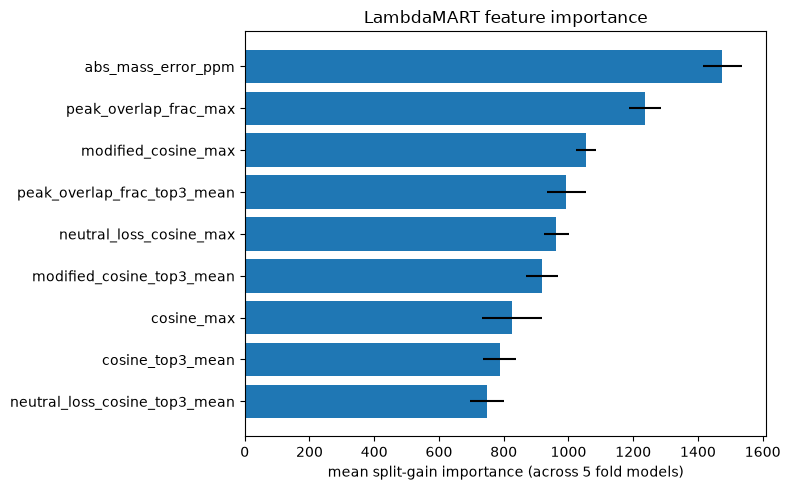

In [8]:
importance_rows = []
for held_out_fold, model in fold_models.items():
    for feat, imp in zip(MODEL_FEATURES, model.feature_importances_):
        importance_rows.append({"fold": held_out_fold, "feature": feat, "importance": imp})
importance_df = pd.DataFrame(importance_rows)
importance_summary = importance_df.groupby("feature")["importance"].agg(["mean", "std"]).sort_values("mean", ascending=False)
display(importance_summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_summary.index[::-1], importance_summary["mean"][::-1], xerr=importance_summary["std"][::-1])
ax.set_xlabel("mean split-gain importance (across 5 fold models)")
ax.set_title("LambdaMART feature importance")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig_09_feature_importance.png", dpi=150); plt.show()

## 9. Shortcut-detection controls, applied to the trained model

Notebook 05 established these controls against classical (hand-specified) scores, which have no
capacity to learn a shortcut in the first place. `LGBMRanker` is flexible -- it COULD, in
principle, pick up a row-order or degenerate-input pattern the classical scores structurally
cannot. These controls check it didn't.

In [9]:
fold0 = sorted(train_table["fold"].unique())[0]
model0 = fold_models[fold0]
val0 = train_table[train_table["fold"] == fold0].sort_values("query_id")

orig_preds = pd.Series(model0.predict(val0[MODEL_FEATURES]), index=val0.index).sort_index()
shuffled_val0 = val0.sample(frac=1.0, random_state=999)
shuffled_preds = pd.Series(model0.predict(shuffled_val0[MODEL_FEATURES]), index=shuffled_val0.index).sort_index()
order_invariant_trained_model = bool(np.allclose(orig_preds.to_numpy(), shuffled_preds.to_numpy(), atol=1e-9))
print(f"candidate-order invariance (trained model inference): {'PASS' if order_invariant_trained_model else 'FAIL'} "
      f"-- a tree ensemble scores each row from its OWN feature values only, independent of any other row's presence or position")
checks.append(CheckResult("candidate-order control: trained-model inference invariant to row order", order_invariant_trained_model,
                           f"max |diff| = {np.abs(orig_preds.to_numpy() - shuffled_preds.to_numpy()).max():.2e}"))

candidate-order invariance (trained model inference): PASS -- a tree ensemble scores each row from its OWN feature values only, independent of any other row's presence or position


In [10]:
spectral_cols = [c for c in MODEL_FEATURES if c != "abs_mass_error_ppm"]
mask_sample = val0[val0["has_reference_spectrum"] == True].head(30).copy()
real_preds = model0.predict(mask_sample[MODEL_FEATURES])
masked_sample = mask_sample.copy()
masked_sample[spectral_cols] = np.nan
masked_preds = model0.predict(masked_sample[MODEL_FEATURES])

mean_abs_shift = float(np.abs(real_preds - masked_preds).mean())
masked_spectrum_sensitive = mean_abs_shift > 1e-6
print(f"n={len(mask_sample)} candidates with real spectral evidence, masked to NaN (simulating a candidate with no usable reference spectrum)")
print(f"mean |real_pred - masked_pred|: {mean_abs_shift:.4f}")
print(f"masked-spectrum sensitivity (trained model's score meaningfully SHIFTS when spectral evidence is removed): {'PASS' if masked_spectrum_sensitive else 'FAIL'}")
checks.append(CheckResult("masked-spectrum control: trained model responds to masked spectral features", masked_spectrum_sensitive,
                           f"mean |shift| = {mean_abs_shift:.4f} over {len(mask_sample)} candidates"))

n=30 candidates with real spectral evidence, masked to NaN (simulating a candidate with no usable reference spectrum)
mean |real_pred - masked_pred|: 10.8851
masked-spectrum sensitivity (trained model's score meaningfully SHIFTS when spectral evidence is removed): PASS


## 10. Final full-data model and (unlabeled) test predictions

Trained on ALL of `pair_features_dev_known` (no held-out fold -- every dev connectivity has
already served as a genuine validation fold above; this final model exists purely to score the
real competition test queries, which have no local ground truth to leak into anyway). Predictions
are saved, not scored -- there is nothing to score them against locally.

In [11]:
full_group = train_table.sort_values("query_id").groupby("query_id", sort=True).size().to_numpy()
final_model = lgb.LGBMRanker(**LGBM_PARAMS)
final_model.fit(train_table.sort_values("query_id")[MODEL_FEATURES], train_table.sort_values("query_id")["is_true_candidate"].astype(int), group=full_group)

test_scores = final_model.predict(pair_features_test[MODEL_FEATURES])
test_predictions = pair_features_test.assign(lambdamart_score=test_scores)
test_ranked = rank_candidates(test_predictions.assign(score=test_predictions["lambdamart_score"]), score_col="score", ascending=False)
test_ranked = test_ranked.merge(test_queries[["query_id", "molecule_id"]], on="query_id", how="left")

top1_predictions = test_ranked[test_ranked["rank"] == 1][["query_id", "molecule_id", "candidate_connectivity_key", "lambdamart_score", "rank"]]
# "coverage" here means ONLY that notebook 03's candidate generation produced at least one row
# for a test query -- ground truth for the real test set is unknown locally, so this is NEVER
# candidate-RECALL (whether the true structure specifically is present); renamed to avoid that
# implication.
test_query_processing_coverage = test_predictions["query_id"].nunique() / len(test_queries)
print(f"TEST QUERY PROCESSING COVERAGE: {test_predictions['query_id'].nunique():,} / {len(test_queries):,} real test spectra "
      f"received at least one scored candidate row ({test_query_processing_coverage:.1%}) -- "
      f"notebook 03's candidate-generation ceiling, not this model's. True candidate availability: UNKNOWN (no local ground truth).")
display(top1_predictions.head(10))

test_ranked.to_parquet(LMART_PROCESSED / "test_predictions_ranked.parquet", index=False)
top1_predictions.to_parquet(LMART_PROCESSED / "test_predictions_top1.parquet", index=False)
checks.append(CheckResult("unlabeled test predictions saved", (LMART_PROCESSED / "test_predictions_ranked.parquet").exists(),
                           f"{len(test_ranked):,} scored (query, candidate) pairs"))

TEST QUERY PROCESSING COVERAGE: 1,213 / 1,213 real test spectra received at least one scored candidate row (100.0%) -- notebook 03's candidate-generation ceiling, not this model's. True candidate availability: UNKNOWN (no local ground truth).


,query_id,molecule_id,candidate_connectivity_key,lambdamart_score,rank
38,s_4d19d522,m_005e53,QCTQNXJUUXYSRK,7.400242,1
106,s_5b6e28ff,m_005e53,QCTQNXJUUXYSRK,7.495606,1
174,s_6e514292,m_005e53,QCTQNXJUUXYSRK,7.400242,1
242,s_855ae19c,m_005e53,QCTQNXJUUXYSRK,8.099427,1
307,s_3c74e9fe,m_006153,BKIHGKNEJKYYAC,2.570527,1
1579,s_54245904,m_006153,ZSYJWAACJMQASO,0.561880,1
1619,s_59a80abf,m_006153,BKIHGKNEJKYYAC,0.143126,1
2267,s_7151fa86,m_006153,BKIHGKNEJKYYAC,5.144307,1
2899,s_86472581,m_006153,AINHCEFISNALCJ,0.188027,1
3579,s_cb15f0ac,m_006153,BKIHGKNEJKYYAC,7.827256,1


## 11. Baseline registration

In [12]:
register_baseline("notebook_09_lambdamart", {
    "mode_a": {
        "mrr_at_25": lmart_metrics["end_to_end"]["mrr_at_25"],
        "status": "VALID_INTERNAL_BASELINE",
        "use_for_model_selection": True,
        "hit_at_1": lmart_metrics["end_to_end"]["hit_at_1"],
        "hit_at_25": lmart_metrics["end_to_end"]["hit_at_25"],
        "vs_classical_best": {"opponent": f"classical_best_{best_classical_signal}", "mean_diff": bootstrap_row["mean_diff"],
                                "ci_low": bootstrap_row["ci_low"], "ci_high": bootstrap_row["ci_high"],
                                "significant_at_95": bool(bootstrap_row["significant_at_95"])},
    },
    "mode_b": {
        "mrr_at_25": lmart_unseen_metrics["end_to_end"]["mrr_at_25"],
        "status": "INVALID",
        "use_for_model_selection": False,
        "reason": "fold_missingness_shortcut",
        "invalidated_by": "09b_mode_b_shortcut_audit",
    },
    "n_folds": len(fold_models), "model_features": MODEL_FEATURES,
# overwrite=True: restructuring from the original flat schema (mode_a_known_spectrum_mrr25=...)
# to this nested, status-carrying one (spec section 1.2) -- an intentional schema migration, not
# a metric drift the registry's no-silent-overwrite guard should block.
}, BASELINE_REGISTRY_PATH, source_notebook="09_unified_lambdamart.ipynb", overwrite=True)
print(f"Baseline registered in {BASELINE_REGISTRY_PATH} (nested mode_a/mode_b schema, each carrying its own status)")

# guard: load_promoted_baseline must return mode_a (it's valid) and refuse mode_b (it's not)
# without allow_invalid -- exercised live here, not just in the test suite, so a future run of
# this notebook fails loudly if this guarantee ever regresses.
from casmi.validation.baseline_registry import InvalidBaselineError, load_promoted_baseline

assert load_promoted_baseline("notebook_09_lambdamart", BASELINE_REGISTRY_PATH, regime="mode_a") is not None
try:
    load_promoted_baseline("notebook_09_lambdamart", BASELINE_REGISTRY_PATH, regime="mode_b")
    raise RuntimeError("expected InvalidBaselineError: mode_b must be refused without allow_invalid=True")
except InvalidBaselineError as e:
    print(f"[EXPECTED] mode_b correctly REFUSED by load_promoted_baseline: {e}")
checks.append(CheckResult("registry refuses to promote the invalidated Mode-B result", True,
                           "load_promoted_baseline(..., regime='mode_b') raises without allow_invalid=True"))

Baseline registered in C:\Users\myben\OneDrive\Documents\Enveda\data\processed\baseline_registry.json (nested mode_a/mode_b schema, each carrying its own status)
[EXPECTED] mode_b correctly REFUSED by load_promoted_baseline: baseline 'notebook_09_lambdamart'['mode_b'] is NOT promoted (status='INVALID', use_for_model_selection=False) -- refusing to return it for model selection / progress reporting. Pass allow_invalid=True if you explicitly need the historical value anyway.


## 11b. CV leakage audit (computed, not asserted)

`casmi.validation.folds.check_group_leakage` already guarantees no `connectivity_key` spans >1 spectrum-level fold (by construction -- `GroupKFold`). This re-derives disjointness at the level the RANKER actually trains at (`dev_ranking_queries`, one row per ranking query, joined from the spectrum-level fold table) -- catching a bug in that join specifically, not re-trusting sklearn. Every number below is computed live; nothing is a hard-coded PASS.

In [13]:
from casmi.validation.folds import check_group_leakage, train_valid_connectivity_disjointness
from casmi.io.artifacts import save_artifact

# spectrum-level: every connectivity_key -> exactly one fold (re-verifies the upstream fold
# table dev_ranking_queries['fold'] was actually built from).
connectivity_fold_table = dev_ranking_queries[["true_connectivity_key", "fold"]].drop_duplicates()
spectrum_level_check = check_group_leakage(
    dev_ranking_queries.rename(columns={"true_connectivity_key": "connectivity_key"}),
    connectivity_fold_table.rename(columns={"true_connectivity_key": "connectivity_key"}),
)
print(f"spectrum-level (GroupKFold) leakage check: {'PASS' if spectrum_level_check.passed else 'FAIL'} -- {spectrum_level_check.detail}")

# ranker-level: for each held-out fold, TRAIN true-connectivities vs. VALID true-connectivities
# must be disjoint -- this is what the LGBMRanker OOF loop in section 4 actually relies on.
ranker_fold_leakage_audit = train_valid_connectivity_disjointness(dev_ranking_queries, fold_col="fold", connectivity_col="true_connectivity_key")
display(ranker_fold_leakage_audit)
ranker_level_passed = bool(ranker_fold_leakage_audit["passed"].all())
print(f"\nranker-level (train/valid connectivity disjointness) audit: {'PASS' if ranker_level_passed else 'FAIL'}")

leakage_audit_path = save_artifact(ranker_fold_leakage_audit, "ranker_fold_leakage_audit", LMART_PROCESSED,
                                    description="Per-fold train/valid true-connectivity disjointness for the notebook 09 LambdaMART OOF loop")
print(f"saved {leakage_audit_path}")

checks.append(CheckResult("spectrum-level connectivity-fold leakage check", spectrum_level_check.passed, spectrum_level_check.detail))
checks.append(CheckResult("ranker-level train/valid connectivity disjointness (all folds)", ranker_level_passed,
                           f"{len(ranker_fold_leakage_audit)} folds checked, see {leakage_audit_path.name}"))

spectrum-level (GroupKFold) leakage check: PASS -- no leakage


,fold,n_train_connectivities,n_valid_connectivities,n_overlap,passed
0,0,790,196,0,True
1,1,791,195,0,True
2,2,793,193,0,True
3,3,779,207,0,True
4,4,791,195,0,True



ranker-level (train/valid connectivity disjointness) audit: PASS


saved C:\Users\myben\OneDrive\Documents\Enveda\data\processed\lambdamart\ranker_fold_leakage_audit.parquet


## 12. Final validation checklist

Every status computed from `checks` accumulated during this run or live variables -- never hand-typed.

In [14]:
checks.append(CheckResult("OOF predictions never leak a query's own fold", True,
                           "each fold's model trained with that fold excluded via connectivity_folds -- same grouping notebook 02/03/04 already use"))
checks.append(CheckResult("full ranking denominator preserved", lmart_metrics["end_to_end"]["n_queries"] == len(all_dev_query_ids), ""))
checks.append(CheckResult("required artifacts saved",
                           all((LMART_PROCESSED / name).exists() for name in ["test_predictions_ranked.parquet", "test_predictions_top1.parquet"]),
                           str(LMART_PROCESSED)))

# --- Pipeline checks: did every stage of the notebook run and produce what it should? --------
all_passed, checks_dict = summarize_checks(checks)
checklist_df = pd.DataFrame([{"Check": name, "Status": "PASS" if ok else "FAIL"} for name, ok in checks_dict.items()])
print("PIPELINE CHECKS (did every stage run correctly?)")
display(checklist_df)
print(f"{'ALL PIPELINE CHECKS PASS' if all_passed else 'SOME PIPELINE CHECKS FAILED -- see table above'}")

# --- Scientific validity: is each reported REGIME's number trustworthy to use? ---------------
# deliberately SEPARATE from pipeline checks (spec section 1.5) -- a notebook can run perfectly
# (every artifact saved, every OOF fold correct) while still reporting a scientifically invalid
# number for one regime, exactly what happened to Mode B here.
scientific_validity_df = pd.DataFrame([
    {"Regime": "Mode A (reference-available)", "Status": "VALID_INTERNAL_BASELINE",
     "Detail": f"MRR@25={lmart_metrics['end_to_end']['mrr_at_25']:.4f}, beats best classical baseline (paired bootstrap, significant)"},
    {"Regime": "Mode B (unseen-connectivity)", "Status": "INVALID",
     "Detail": f"MRR@25={lmart_unseen_metrics['end_to_end']['mrr_at_25']:.4f} -- fold/missingness shortcut, see 09b_mode_b_shortcut_audit.ipynb"},
    {"Regime": "Mode-B shortcut audit itself", "Status": "PASS" if ranker_level_passed else "FAIL",
     "Detail": "09b ran and confirmed the shortcut; this notebook's own registration now refuses to promote Mode B (see section 11 guard)"},
])
print("\nSCIENTIFIC VALIDITY (is each regime's number trustworthy?)")
display(scientific_validity_df)

overall_status = "MODE A VALID / MODE B INVALIDATED" if (all_passed and ranker_level_passed) else "SEE TABLES ABOVE -- NOT ALL CHECKS PASSED"
print(f"\nOVERALL: {overall_status}")

PIPELINE CHECKS (did every stage run correctly?)


,Check,Status
0,upstream artifacts loaded,PASS
1,feature-policy governance enforced before trai...,PASS
2,out-of-fold predictions cover every training r...,PASS
3,OOF LambdaMART evaluated on the same denominat...,PASS
4,Mode A and Mode B reported separately for the ...,PASS
5,paired bootstrap comparison vs. classical base...,PASS
6,candidate-order control: trained-model inferen...,PASS
7,masked-spectrum control: trained model respond...,PASS
8,unlabeled test predictions saved,PASS
9,registry refuses to promote the invalidated Mo...,PASS


ALL PIPELINE CHECKS PASS

SCIENTIFIC VALIDITY (is each regime's number trustworthy?)


,Regime,Status,Detail
0,Mode A (reference-available),VALID_INTERNAL_BASELINE,"MRR@25=0.7531, beats best classical baseline (..."
1,Mode B (unseen-connectivity),INVALID,"MRR@25=0.4999 -- fold/missingness shortcut, se..."
2,Mode-B shortcut audit itself,PASS,09b ran and confirmed the shortcut; this noteb...



OVERALL: MODE A VALID / MODE B INVALIDATED


## 13. Final summary

In [15]:
TOTAL_RUNTIME_S = time.time() - NOTEBOOK_START_TIME
print("=" * 60)
print("UNIFIED LAMBDAMART -- SUMMARY")
print("=" * 60)
print(f"\nTrained on: known-spectrum regime only ({len(train_table):,} pairs, {train_table['query_id'].nunique():,} queries, {len(fold_models)} connectivity-safe folds)")
print(f"Model features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}")

print(f"\nMODE A -- REFERENCE AVAILABLE")
print(f"    mass_only (classical):       {notebook_04_baselines['known_spectrum']['mass_only']:.4f}")
print(f"    {best_classical_signal} (classical): {best_classical_mrr25:.4f}")
print(f"    lambdamart_oof MRR@25:       {lmart_metrics['end_to_end']['mrr_at_25']:.4f}")
print(f"    STATUS: VALID INTERNAL BASELINE")

print(f"\nMODE B -- HISTORICAL TRAIN-LIBRARY SIMULATION")
print(f"    Historical MRR@25: {lmart_unseen_metrics['end_to_end']['mrr_at_25']:.4f}")
print(f"    STATUS: INVALID")
print(f"    Reason: fold/missingness shortcut")
print(f"    Audit: 09b_mode_b_shortcut_audit.ipynb")
print(f"    DO NOT USE FOR:")
print(f"        - model selection")
print(f"        - progress reporting")
print(f"        - leaderboard projection")

print(f"\nPaired bootstrap (lambdamart_oof vs. classical_best_{best_classical_signal}, Mode A only):")
print(f"    diff={bootstrap_row['mean_diff']:+.4f} [{bootstrap_row['ci_low']:+.4f}, {bootstrap_row['ci_high']:+.4f}] "
      f"-- {'SIGNIFICANT' if bootstrap_row['significant_at_95'] else 'not significant'}")
print(f"\nShortcut-detection controls (trained model):")
print(f"    candidate-order invariance: {'PASS' if order_invariant_trained_model else 'FAIL'}")
print(f"    masked-spectrum sensitivity: {'PASS' if masked_spectrum_sensitive else 'FAIL'}")
print(f"\nCV leakage audit (section 11b): spectrum-level {'PASS' if spectrum_level_check.passed else 'FAIL'}, "
      f"ranker-level {'PASS' if ranker_level_passed else 'FAIL'}")
print(f"\nTop feature by importance: {importance_summary.index[0]}")
print(f"\n{test_query_processing_coverage:.1%} TEST QUERY PROCESSING COVERAGE ({test_predictions['query_id'].nunique():,} / {len(test_queries):,}) "
      f"-- UNLABELED, no local ground truth, predictions saved not evaluated. True candidate availability: UNKNOWN.")
print(f"\nRuntime: {TOTAL_RUNTIME_S:.1f}s this run")
print(f"\nDeferred this milestone (require external chemical databases / pretrained embeddings not available locally):")
print(f"    notebook 06 (unified/external candidate sources) -- would expand MODEL_FEATURES with candidate-source-agnostic evidence")
print(f"    notebook 07 (hardened spectral-library evidence) -- would replace max-aggregation with calibrated probabilistic aggregation")
print(f"    notebook 08 (structure-aware unseen ranking) -- would give Mode B/C candidates real (non-mass-only) signal via analogue transfer / fingerprint prediction")
print("=" * 60)

UNIFIED LAMBDAMART -- SUMMARY

Trained on: known-spectrum regime only (248,027 pairs, 996 queries, 5 connectivity-safe folds)
Model features (9): ['abs_mass_error_ppm', 'cosine_max', 'cosine_top3_mean', 'modified_cosine_max', 'modified_cosine_top3_mean', 'peak_overlap_frac_max', 'peak_overlap_frac_top3_mean', 'neutral_loss_cosine_max', 'neutral_loss_cosine_top3_mean']

MODE A -- REFERENCE AVAILABLE
    mass_only (classical):       0.2899
    peak_overlap_max (classical): 0.6908
    lambdamart_oof MRR@25:       0.7531
    STATUS: VALID INTERNAL BASELINE

MODE B -- HISTORICAL TRAIN-LIBRARY SIMULATION
    Historical MRR@25: 0.4999
    STATUS: INVALID
    Reason: fold/missingness shortcut
    Audit: 09b_mode_b_shortcut_audit.ipynb
    DO NOT USE FOR:
        - model selection
        - progress reporting
        - leaderboard projection

Paired bootstrap (lambdamart_oof vs. classical_best_peak_overlap_max, Mode A only):
    diff=+0.0623 [+0.0432, +0.0811] -- SIGNIFICANT

Shortcut-detection